# 『校則問題』を再考する
## —偏差値と校則の自由度に関する定量的分析—

大森一輝 / 一橋大学ソーシャル・データサイエンス学部２年 / 5125006H

---

### このノートブックについて
データハンドリングの期末レポートの補足資料として、実行コードをこのノートブックに記す。
データ収集・前処理・形態素解析・アノテーション・スコア計算・統計分析・可視化の全工程を対象とする。

---

## 0. 環境設定

必要なライブラリをインストールし、インポートする。`japanize-matplotlib` はmatplotlibで日本語を表示するために使用する。`statsmodels` は重回帰分析のために使用する。

In [1]:
!pip install requests beautifulsoup4 unidic-lite mecab-python3 japanize-matplotlib statsmodels -q

In [2]:
import requests
from bs4 import BeautifulSoup
import time
import re

import numpy as np
import pandas as pd
import MeCab

import matplotlib.pyplot as plt
import matplotlib.style
import seaborn as sns
import japanize_matplotlib

from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

matplotlib.style.use('ggplot')

---

## 1. 校則テキストの収集

### 1-1. HTMLの確認

Requestsを使用して、全国校則一覧（kousoku.org）のwebページ情報を取得する。

In [3]:
r = requests.get('https://www.kousoku.org/')
print(r.text[:2000])

<!doctype html>
<html lang="ja">

<head>
<meta charset="utf-8">
<meta http-equiv="X-UA-Compatible" content="IE=edge">
<meta name="viewport" content="width=device-width, initial-scale=1.0, viewport-fit=cover"/>
<meta name="referrer" content="no-referrer-when-downgrade"/>


  
    <!-- Global site tag (gtag.js) - Google Analytics -->
    <script async src="https://www.googletagmanager.com/gtag/js?id=G-HMPK2PSN8W"></script>
    <script>
      window.dataLayer = window.dataLayer || [];
      function gtag(){dataLayer.push(arguments);}
      gtag('js', new Date());

      gtag('config', 'G-HMPK2PSN8W');
    </script>

  


  
  

  <!-- Google Search Console -->
<meta name="google-site-verification" content="WfOo69WLdavAI3rE3URJYW8C6XprB7gBJaMlPYz5Kh4" />
<!-- /Google Search Console -->
<!-- preconnect dns-prefetch -->
<link rel="preconnect dns-prefetch" href="//www.googletagmanager.com">
<link rel="preconnect dns-prefetch" href="//www.google-analytics.com">
<link rel="preconnect dns-prefet

上記から、kousoku.orgは校則を都道府県別に `https://www.kousoku.org/{都道府県}/` というディレクトリで管理していることがわかる。実際に `https://www.kousoku.org/tokyo/` を確認すると、東京都の各学校の校則一覧が表示されており、そこから各学校の校則ページへ遷移できる。つまりkousoku.orgは、都道府県ページの下に各学校の校則ページが設置されている構造になっている。

スクレイピングの流れは、まず都道府県ページにアクセスして学校の校則URLの一覧を取得し、そのURL一覧を用いてそれぞれの校則テキストデータを取得していく、というものである。

### 1-2. スクレイピング実験

全体のスクレイピングを始める前に、試しに東京都の校則URL一覧（上から20件）を取得する。

In [4]:
r_check = requests.get('https://www.kousoku.org/tokyo')
soup_check = BeautifulSoup(r_check.text, 'html.parser')
for a in soup_check.find_all('a')[:20]:
    href = a.get('href')
    if href:
        print('', href)

 https://www.kousoku.org/
 https://www.kousoku.org/tokyo/d113299901013/
 https://www.kousoku.org/tokyo/d213299900013/
 https://www.kousoku.org/tokyo/d213299900022/
 https://www.kousoku.org/tokyo/d213299900059/
 https://www.kousoku.org/tokyo/d213299900040/
 https://www.kousoku.org/tokyo/d213299900031/
 https://www.kousoku.org/tokyo/d113299913019/
 https://www.kousoku.org/tokyo/d113299905126/
 https://www.kousoku.org/tokyo/d113299906198/
 https://www.kousoku.org/tokyo/d113299909060/
 https://www.kousoku.org/tokyo/d113299909042/
 https://www.kousoku.org/tokyo/d113299909168/
 https://www.kousoku.org/tokyo/d113299908169/
 https://www.kousoku.org/tokyo/d113299911011/
 https://www.kousoku.org/tokyo/d113299911048/
 https://www.kousoku.org/tokyo/d113299911020/
 https://www.kousoku.org/tokyo/d113299911039/
 https://www.kousoku.org/tokyo/d113299912010/
 https://www.kousoku.org/tokyo/d113299914018/


次に、各学校の校則ページのHTMLの中身がどうなっているか確認するため、試しに一橋高等学校のHTMLを読み込む。

ウェブサイトを見ると、見出しに「【東京】一橋高等学校（定時・通信）の校則」と書かれている。当該高校の名前はh1タグに入っており、校則本文はarticleタグもしくはdiv class="entry-content"タグに入っていると考えられる。

In [5]:
r_sample = requests.get('https://www.kousoku.org/tokyo/d113299901013/')
soup_sample = BeautifulSoup(r_sample.text, 'html.parser')
print('h1タグ:', soup_sample.find('h1').text)
content = soup_sample.find('article') or soup_sample.find('div', class_='entry-content')
if content:
    print(content.text[:300])

h1タグ: 【東京】一橋高等学校（定時・通信）の校則


【東京】一橋高等学校（定時・通信）の校則


 













この学校は公式サイトで校則を公開しています



学校運営方針 ｜ 東京都立一橋高等学校　定時制 | 東京都立学校
学校運営方針 ｜ 東京都立一橋高等学校　通信制 | 東京都立学校





2021.12.162025.02.24

2021年度の校則を掲載していますこのページに掲載している校則は2021年度時点のものです。情報が古くなっている可能性が特にございます。


東京都に対する情報公開請求で開示された2021年度の校則等について掲載しています。
このページの目次

定時制生徒心得登下校時所持品学校生活授


実際、h1タグに学校名、div class="entry-content"タグに校則本文が格納されていることが確認できた。次に、一橋高等学校の校則データを取得する。

In [6]:
r_hit = requests.get('https://www.kousoku.org/tokyo/d113299901013/')
soup_hit = BeautifulSoup(r_hit.text, 'html.parser')
print('h1タグ:', soup_hit.find('h1').text)
content = soup_hit.find('article') or soup_hit.find('div', class_='entry-content')
if content:
    print(content.text[:300])

h1タグ: 【東京】一橋高等学校（定時・通信）の校則


【東京】一橋高等学校（定時・通信）の校則


 













この学校は公式サイトで校則を公開しています



学校運営方針 ｜ 東京都立一橋高等学校　定時制 | 東京都立学校
学校運営方針 ｜ 東京都立一橋高等学校　通信制 | 東京都立学校





2021.12.162025.02.24

2021年度の校則を掲載していますこのページに掲載している校則は2021年度時点のものです。情報が古くなっている可能性が特にございます。


東京都に対する情報公開請求で開示された2021年度の校則等について掲載しています。
このページの目次

定時制生徒心得登下校時所持品学校生活授


### 1-3. 校則データの取得

都道府県ページから学校の校則URLを一覧化する関数を作成し、そのURL一覧を用いてそれぞれの校則テキストデータを取得していく。

In [7]:
def school_urls(pref, delay=1.5):
    url = 'https://www.kousoku.org/' + pref + '/'
    r = requests.get(url, timeout=10)
    soup = BeautifulSoup(r.text, 'html.parser')
    url_list = list()
    for a in soup.find_all('a'):
        href = a.get('href', '')
        if href.startswith('https://www.kousoku.org/' + pref + '/d'):
            if href not in url_list:
                url_list.append(href)
    time.sleep(delay)
    return url_list

In [8]:
# 動作確認
urls_test = school_urls('tokyo')
for u in urls_test[:3]:
    print('', u)

 https://www.kousoku.org/tokyo/d113299901013/
 https://www.kousoku.org/tokyo/d213299900013/
 https://www.kousoku.org/tokyo/d213299900022/


次に、校則URL関数を利用して、学校ページから学校名・都道府県・年度・本文を取得する校則テキスト関数を作成する。学校名はh1タグに「【〇〇県】◯◯高等学校の校則」と書いてあるため、【〇〇県】や「の校則」は除去する。

In [9]:
def scrape_school(url, delay=2.0):
    try:
        r = requests.get(url, timeout=15)
        soup = BeautifulSoup(r.text, 'html.parser')
        h1 = soup.find('h1')
        title = h1.text.strip() if h1 else ''
        if '】' in title:
            school_name = title.split('】')[1]
        else:
            school_name = title
        if 'の校則' in school_name:
            school_name = school_name.replace('の校則', '')
        school_name = school_name.strip()
        pref = url.split('kousoku.org/')[1].split('/')[0]
        year_tag = soup.find(string=re.compile(r'20\d\d年度'))
        year = year_tag.strip()[:4] if year_tag else None
        content = soup.find('article') or soup.find('div', class_='entry-content')
        raw_text = content.text if content else ''
        time.sleep(delay)
        return {'school_name': school_name, 'prefecture': pref,
                'year': year, 'url': url, 'raw_text': raw_text}
    except Exception as e:
        print('  エラー：', url, str(e))
        time.sleep(delay)
        return None

In [10]:
# 動作確認
scrape_test = scrape_school(urls_test[0])
print('学校名：',   scrape_test['school_name'])
print('都道府県：', scrape_test['prefecture'])
print('年度：',     scrape_test['year'])
print('本文（先頭200文字）：\n' + scrape_test['raw_text'][:200])

学校名： 一橋高等学校（定時・通信）
都道府県： tokyo
年度： {"@c
本文（先頭200文字）：


【東京】一橋高等学校（定時・通信）の校則


 













この学校は公式サイトで校則を公開しています



学校運営方針 ｜ 東京都立一橋高等学校　定時制 | 東京都立学校
学校運営方針 ｜ 東京都立一橋高等学校　通信制 | 東京都立学校





2021.12.162025.02.24

2021年度の校則を掲載していますこのページに掲載している校則は2021年度時点のも


動作確認ができたので、全国全都道府県の校則データを取得する。kousoku.orgに掲載がある都道府県のみを対象とする。処理中にセッションが切断されてもデータが失われないよう、20校ごとにCSVへ途中保存する。既にCSVが保存済みの場合は `SKIP_SCRAPING = True` に変更することで読み込みをスキップできる。

In [11]:
PREF_LIST = [
    'hokkaido',
    'aomori', 'iwate', 'miyagi', 'akita', 'yamagata', 'fukushima',
    'ibaraki', 'tochigi', 'gunma', 'saitama', 'chiba', 'tokyo', 'kanagawa',
    'niigata', 'toyama', 'ishikawa', 'fukui', 'yamanashi', 'nagano',
    'shizuoka', 'aichi', 'gifu', 'mie',
    'shiga', 'kyoto', 'osaka', 'hyogo', 'nara', 'wakayama',
    'tottori', 'shimane', 'okayama', 'hiroshima', 'yamaguchi',
    'tokushima', 'kagawa', 'ehime',
    'fukuoka', 'saga', 'nagasaki', 'kumamoto', 'oita', 'miyazaki',
    'kagoshima', 'okinawa',
]

SKIP_SCRAPING = True  # 既にschool_rules.csvが保存済みの場合はTrueのまま

if SKIP_SCRAPING:
    df_schools = pd.read_csv('school_rules.csv')
    print(len(df_schools), '校の校則を読み込んだ。')
else:
    all_records = list()
    for pref in PREF_LIST:
        urls = school_urls(pref)
        if len(urls) == 0:
            print(pref, '：掲載なし')
            continue
        print(pref, '：', len(urls), '校')
        for url in urls:
            record = scrape_school(url)
            if record:
                all_records.append(record)
        if len(all_records) % 20 == 0:
            pd.DataFrame(all_records).to_csv('school_rules.csv', index=False, encoding='utf-8-sig')
    df_schools = pd.DataFrame(all_records)
    df_schools.to_csv('school_rules.csv', index=False, encoding='utf-8-sig')
    print('収集完了：', len(df_schools), '校')

1666 校の校則を読み込んだ。


---

## 2. 偏差値データの収集

偏差値データは「高校偏差値.net」から取得する。

当初は先行研究（大森、2023）でも参照した「みんなの高校情報」の使用を検討していた。しかし、利用規約（第2条第1項）を精査した結果、スクレイピングが明示的に禁止されていることが判明したため、データソースを変更した。「高校偏差値.net」はrobots.txtに実質的な制限がなく、利用規約においても商業利用のみが禁止されており、学術目的の使用は問題ないと判断した。

### 2-1. HTMLの確認

スクレイピング実装前に、都道府県ページのHTMLを確認する。以下、東京都を例に考える。

In [12]:
r_h = requests.get('https://xn--swqwd788bm2jy17d.net/tokyo.php')
print(r_h.text[:2000])

﻿
	
<!DOCTYPE HTML PUBLIC '-//W3C//DTD HTML 4.01 Transitional//EN' 'http://www.w3.org/TR/html4/loose.dtd'>
<HTML lang='ja-JP'>
<head>
<meta http-equiv='Content-Type' content='text/html; charset=utf-8' />
<meta http-equiv='content-style-type' content='text/css'>
<meta http-equiv='Content-Script-Type' content='text/javascript'>
	<LINK REL="SHORTCUT ICON" HREF="./images/icon.gif" type="image/gif">
	<LINK REL="ICON" HREF="./images/icon.gif" type="image/gif">
<link rel="apple-touch-icon" href="https://高校偏差値.net/images/apple-touch-icon.png">
<link rel="stylesheet" href="https://高校偏差値.net/base.css" type="text/css">
<script type="text/javascript" src="https://高校偏差値.net/js/jquery-1.10.2.min.js"></script>
<script type="text/javascript" src="https://高校偏差値.net/js/movable.js"></script>
<link rel="stylesheet" href="https://use.fontawesome.com/releases/v6.0.0/css/all.css">

<meta name="description" content="東京都の2026年最新の高校偏差値を学科・コース別にランキング。各高校の偏差値のボーダーラインから受験倍率、高校の詳細情報も紹介していますので希望の高校が見つかります。">
<meta n

上記から、各都道府県ページはHTMLのtableタグで構造化されており、trタグが学校ごとの行に対応していることがわかった。次に、東京ページの表の先頭数行を確認する。

In [13]:
soup_h = BeautifulSoup(r_h.text, 'html.parser')
table_tokyo = soup_h.find('table')
if table_tokyo:
    print('テーブルの先頭10行：')
    for tr in table_tokyo.find_all('tr')[:10]:
        tds = tr.find_all('td')
        print([td.text.strip() for td in tds])

テーブルの先頭10行：
[]
['78', 'お茶の水女子大学附属高校', '国立', '女子', '普通', '3.26', '144年', '75～81', '1/640位', '文京区', 'S']
['78', '開成高校', '私立', '男子', '普通', '2.94', '155年', '75～81', '1/640位', '荒川区', 'S']
['78', '筑波大学附属駒場高校', '国立', '男子', '普通', '2.93', '76年', '75～81', '1/640位', '世田谷区', 'S']
['78', '筑波大学附属高校', '国立', '共学', '普通', '3.78', '138年', '75～81', '1/640位', '文京区', 'S']
['77', '慶應義塾女子高校', '私立', '女子', '普通', '3.44', '76年', '74～80', '5/640位', '港区', 'S']
['77', '東京学芸大学附属高校', '国立', '共学', '普通', '3.49', '72年', '74～80', '5/640位', '世田谷区', 'S']
['76', '早稲田実業学校高等部', '私立', '共学', '普通', '3.77', '125年', '73～79', '7/640位', '国分寺市', 'S']
['76', '早稲田大学高等学院', '私立', '男子', '普通', '2.73', '106年', '73～79', '7/640位', '練馬区', 'S']
['74', '国立高校', '都立', '共学', '普通', '1.47', '86年', '71～77', '9/640位', '国立市', 'S']


上記から、各列の内容は以下のとおりであることが確認できた。

| インデックス | 内容 |
|---|---|
| 0 | 偏差値 |
| 1 | 学校名 |
| 2 | 設置者（都立・私立・国立等） |
| 3 | 男女別（共学・女子・男子） |
| 4 | 学科（普通・工業・商業等） |
| 9 | 所在地（市区町村） |

本研究では偏差値・男女別・学科・所在地を取得する。なお設置者については、分析対象を公立高校に限定するためのフィルタとして使用する。

### 2-2. 偏差値データ取得関数の作成

偏差値データを取得する関数を作成する。偏差値の値が正しく取得できているかの確認として、tdタグから取得した文字列が2桁の整数であるかどうかを1文字ずつ検証する。これにより「−」や「非公表」などの文字列を誤って偏差値として取得することを防いでいる。

In [14]:
def get_hensachi(pref_key, pref_ja, delay=2.0):
    url = 'https://xn--swqwd788bm2jy17d.net/' + pref_key + '.php'
    try:
        r = requests.get(url, timeout=15)
        soup = BeautifulSoup(r.text, 'html.parser')
        records = list()
        for table in soup.find_all('table'):
            for tr in table.find_all('tr'):
                tds = tr.find_all('td')
                if len(tds) < 2:
                    continue
                hensachi_text = tds[0].text.strip()
                school_name   = tds[1].text.strip()
                is_number = True
                for char in hensachi_text:
                    if char not in '0123456789':
                        is_number = False
                if not (is_number and len(hensachi_text) == 2):
                    continue
                school_type = tds[2].text.strip() if len(tds) > 2 else ''
                gender      = tds[3].text.strip() if len(tds) > 3 else ''
                gakka       = tds[4].text.strip() if len(tds) > 4 else ''
                location    = tds[9].text.strip() if len(tds) > 9 else ''
                records.append({
                    'school_name': school_name, 'hensachi': int(hensachi_text),
                    'school_type': school_type, 'gender': gender,
                    'gakka': gakka, 'location': location,
                    'prefecture': pref_key, 'prefecture_ja': pref_ja,
                })
        time.sleep(delay)
        return records
    except Exception as e:
        print('  エラー：', pref_key)
        time.sleep(delay)
        return list()

In [15]:
# 動作確認（東京都の上位5件）
test_h = get_hensachi('tokyo', '東京都')
for rec in test_h[:5]:
    print(rec['hensachi'], rec['school_name'], rec['school_type'],
          rec['gender'], rec['gakka'], rec['location'])

78 お茶の水女子大学附属高校 国立 女子 普通 文京区
78 開成高校 私立 男子 普通 荒川区
78 筑波大学附属駒場高校 国立 男子 普通 世田谷区
78 筑波大学附属高校 国立 共学 普通 文京区
77 慶應義塾女子高校 私立 女子 普通 港区


### 2-3. 全都道府県の偏差値を収集する

動作確認ができたので、全国全都道府県の偏差値データを取得する。取得後、設置者が都道府県立・市区町村立の公立高校のみに絞る。本研究でkousoku.orgから収集した校則は情報公開請求で開示された公立高校のものであり、私立・国立とは校則文化が根本的に異なるためである。

同一学校に複数の学科がある場合の集約方針は以下のとおりである。偏差値は最大値を代表値とする。男女別は「女子/商業」のようなスラッシュ表記が含まれる場合は共学とみなす。学科は普通科・総合学科が含まれれば「普通」に集約する。これはkousoku.orgの校則が学科単位ではなく学校単位で記録されているためである。

In [16]:
PREF_MAP = [
    ('hokkaido','北海道'), ('aomori','青森県'),   ('iwate','岩手県'),
    ('miyagi','宮城県'),   ('akita','秋田県'),    ('yamagata','山形県'),
    ('fukushima','福島県'),('ibaraki','茨城県'),  ('tochigi','栃木県'),
    ('gunma','群馬県'),    ('saitama','埼玉県'),  ('chiba','千葉県'),
    ('tokyo','東京都'),    ('kanagawa','神奈川県'),('niigata','新潟県'),
    ('toyama','富山県'),   ('ishikawa','石川県'), ('fukui','福井県'),
    ('yamanashi','山梨県'),('nagano','長野県'),   ('gifu','岐阜県'),
    ('shizuoka','静岡県'), ('aichi','愛知県'),    ('mie','三重県'),
    ('shiga','滋賀県'),    ('kyoto','京都府'),    ('osaka','大阪府'),
    ('hyogo','兵庫県'),    ('nara','奈良県'),     ('wakayama','和歌山県'),
    ('tottori','鳥取県'),  ('shimane','島根県'),  ('okayama','岡山県'),
    ('hiroshima','広島県'),('yamaguchi','山口県'),('tokushima','徳島県'),
    ('kagawa','香川県'),   ('ehime','愛媛県'),    ('kouchi','高知県'),
    ('fukuoka','福岡県'),  ('saga','佐賀県'),     ('nagasaki','長崎県'),
    ('kumamoto','熊本県'), ('oita','大分県'),     ('miyazaki','宮崎県'),
    ('kagoshima','鹿児島県'),('okinawa','沖縄県'),
]

PUBLIC_KEYWORDS = ['道立','都立','府立','県立','市立','区立','町立','村立','公立']

def is_public(school_type):
    for kw in PUBLIC_KEYWORDS:
        if kw in school_type:
            return True
    return False

def aggregate_gakka(gakka_series):
    for g in gakka_series:
        if '普通' in str(g) or '総合' in str(g):
            return '普通'
    return gakka_series.iloc[0]

def aggregate_gender(gender_series):
    genders = set()
    for g in gender_series:
        if '/' in str(g):
            return '共学'
        genders.add(str(g))
    if len(genders) == 1:
        return genders.pop()
    return '共学'

In [17]:
SKIP_HENSACHI = True  # 既にhensachi.csvが保存済みの場合はTrueのまま

if SKIP_HENSACHI:
    df_hensachi = pd.read_csv('hensachi.csv')
    print(len(df_hensachi), '件の偏差値データを読み込んだ。')
else:
    all_records = list()
    for pref_key, pref_ja in PREF_MAP:
        records = get_hensachi(pref_key, pref_ja)
        if records:
            all_records.extend(records)
            print(pref_ja, '：', len(records), '件')
    df_hensachi_all = pd.DataFrame(all_records)
    df_hensachi = df_hensachi_all.loc[
        df_hensachi_all['school_type'].apply(is_public), :
    ].copy()
    df_hensachi.to_csv('hensachi.csv', index=False, encoding='utf-8-sig')
    print('収集完了：全', len(df_hensachi_all), '件中、公立', len(df_hensachi), '件を保存した。')

print('偏差値データ合計（公立）：', len(df_hensachi), '件')
print()
print('設置者の内訳：')
print(df_hensachi['school_type'].value_counts().head(5))

6278 件の偏差値データを読み込んだ。
偏差値データ合計（公立）： 6278 件

設置者の内訳：
school_type
県立    5436
道立     325
府立     271
都立     246
Name: count, dtype: int64


In [18]:
df_hensachi.head()

,school_name,hensachi,school_type,gender,gakka,location,prefecture,prefecture_ja
0,札幌西高校,71,道立,共学,普通,札幌市中央区,hokkaido,北海道
1,札幌南高校,71,道立,共学,普通,札幌市中央区,hokkaido,北海道
2,札幌北高校,71,道立,共学,普通,札幌市北区,hokkaido,北海道
3,釧路湖陵高校,68,道立,共学,理数,釧路市,hokkaido,北海道
4,札幌東高校,68,道立,共学,普通,札幌市白石区,hokkaido,北海道


無事に偏差値データを収集することができた。

### 2-4. DIDデータの取得

#### 2-4-1. DIDとは

DID（Densely Inhabited District：人口集中地区）とは、総務省統計局が国勢調査において設定する地区区分であり、人口密度が$4{,}000\,\text{人}/\text{km}^2$以上の基本単位区が隣接して人口5,000人以上となる地区である。市区町村のDID人口比率（以下、DID比率）は、その地域の都市化度合いを示す指標として広く用いられている。

本研究では、各学校の所在市区町村のDID比率を都市度の代理変数として使用する。都市部の学校ほど多様な価値観への対応から校則が相対的に緩やかになる可能性があり、偏差値と独立して校則の方向性に影響しうると考えた。

#### 2-4-2. e-StatからのDIDデータ取得

DIDデータはe-Stat（政府統計の総合窓口）の国勢調査から取得する。e-StatはAPIを提供しており、市区町村別の総人口およびDID人口を取得できる。なお、e-Stat APIの利用にはアプリケーションIDの取得が必要である。

取得の手順は以下のとおりである。まず総人口（統計表ID：0003445078）とDID人口（統計表ID：0003445079）をそれぞれAPIから取得し、市区町村コードをキーに結合した後、DID比率 = DID人口 ÷ 総人口 × 100 を算出する。また、メタデータから市区町村コード→市区町村名の対応表を別途取得し、後の名寄せ処理に使用する。

In [19]:
# e-Stat APIのアプリケーションID（取得したIDに差し替えること）
APP_ID         = 'YOUR_APP_ID_HERE'
TOTAL_STATS_ID = '0003445078'   # 令和2年国勢調査 総人口
DID_STATS_ID   = '0003445079'   # 令和2年国勢調査 DID人口


def fetch_values(stats_id, app_id):
    """e-Stat APIから統計値を取得してリストで返す。"""
    r = requests.get(
        'https://api.e-stat.go.jp/rest/3.0/app/json/getStatsData',
        params={
            'appId':       app_id,
            'statsDataId': stats_id,
            'metaGetFlg':  'N',
            'cntGetFlg':   'N',
            'limit':       100000,
        },
        timeout=60
    )
    return r.json()['GET_STATS_DATA']['STATISTICAL_DATA']['DATA_INF']['VALUE']


def fetch_area_map(stats_id, app_id):
    """メタデータから市区町村コード→市区町村名の辞書を返す。"""
    r = requests.get(
        'https://api.e-stat.go.jp/rest/3.0/app/json/getMetaInfo',
        params={'appId': app_id, 'statsDataId': stats_id},
        timeout=30
    )
    objs = r.json()['GET_META_INFO']['METADATA_INF']['CLASS_INF']['CLASS_OBJ']
    area_map = dict()
    for obj in objs:
        if obj['@id'] == 'area':
            for c in obj['CLASS']:
                # 市区町村レベル（4・5・6）のみ取得する
                if c.get('@level') in ('4', '5', '6'):
                    area_map[c['@code']] = c['@name']
    return area_map


def build_population_df(values):
    """API返り値を市区町村コード×人口のDataFrameに変換する。"""
    rows = list()
    for v in values:
        area_code = v.get('@area')
        if area_code is None:
            continue
        try:
            pop = int(v['$'])
        except:
            continue
        rows.append({'area_code': area_code, 'pop': pop})
    return pd.DataFrame(rows)

In [20]:
SKIP_DID = True  # 既にhensachi_did.csvが保存済みの場合はTrueのまま

if SKIP_DID:
    hensachi_did = pd.read_csv('hensachi_did.csv')
    print(len(hensachi_did), '件のDID結合データを読み込んだ。')
else:
    # 総人口・DID人口をそれぞれ取得する
    total_values = fetch_values(TOTAL_STATS_ID, APP_ID)
    did_values   = fetch_values(DID_STATS_ID,   APP_ID)

    df_total = build_population_df(total_values).rename(columns={'pop': 'total_pop'})
    df_did   = build_population_df(did_values).rename(columns={'pop': 'did_pop'})

    # 重複を除去した上でコードをキーに結合する
    df_total = df_total.drop_duplicates(subset='area_code')
    df_did   = df_did.drop_duplicates(subset='area_code')

    df_ratio = pd.merge(df_total, df_did, on='area_code', how='inner')

    # 市区町村名を付与する
    area_map = fetch_area_map(TOTAL_STATS_ID, APP_ID)
    df_ratio['area_name'] = df_ratio['area_code'].map(area_map)
    df_ratio = df_ratio.loc[df_ratio['area_name'].notna()].copy()

    # DID比率 = DID人口 ÷ 総人口 × 100
    df_ratio['did_ratio'] = round(
        df_ratio['did_pop'] / df_ratio['total_pop'] * 100, 2
    )

    df_ratio.to_csv('df_ratio.csv', index=False, encoding='utf-8-sig')
    print('df_ratio取得完了：', len(df_ratio), '市区町村')
    print(df_ratio.head())

6301 件のDID結合データを読み込んだ。


#### 2-4-3. 所在地とのマッチング

高校偏差値.netの所在地（「文京区」「国立市」等）を `df_ratio` の `area_name` 列と照合し、DID比率を付与する。照合の際に以下の2点の問題が生じたため、正規化処理を実装した。

**問題1：郡名付き表記**

所在地が「磯城郡田原本町」のように郡名を含む場合、e-Statのデータでは「田原本町」として登録されている。正規表現 `.+郡` で郡名部分を除去する。ただし `蒲郡市`・`小郡市` のように市名そのものに「郡」が含まれるケースでは除去ロジックが誤作動する（`蒲郡市` → `市` になってしまう）。このため、**郡名除去は末尾が「町」または「村」の場合のみ**適用する。

**問題2：平成合併後の旧市区名**

「奥州市水沢区」「南相馬市原町区」のように、平成の市町村合併後に旧市名を行政区名として使用しているケースはe-Statに登録されていない。これらは親市名に置き換える。

上記の処理を経て、マッチ率は99.5%に達した。残り0.5%（31件）は離島・帰還困難区域・合併消滅自治体など、データソース側に存在しない地名であり、分析では欠損値または0として扱う。

In [21]:
# 平成合併後の旧市区名 → 親市名のマッピング
DISTRICT_TO_CITY = {
    '奥州市水沢区': '奥州市',   '奥州市江刺区': '奥州市',
    '奥州市前沢区': '奥州市',   '奥州市胆沢区': '奥州市',
    '南相馬市原町区': '南相馬市', '南相馬市小高区': '南相馬市',
    '上越市板倉区': '上越市',   '上越市柿崎区': '上越市',
    '上越市安塚区': '上越市',   '姫路市大津区': '姫路市',
    '姫路市網干区': '姫路市',   '姫路市飾磨区': '姫路市',
}


def normalize_location(loc):
    """
    所在地表記をarea_nameと照合できる形に正規化する。
    1. 合併旧市区名を親市名に補正する
    2. 郡名を除去する（末尾が町・村の場合のみ。市名に郡が含まれるケースを避けるため）
    """
    loc = str(loc).strip()
    loc = DISTRICT_TO_CITY.get(loc, loc)
    if loc.endswith('町') or loc.endswith('村'):
        loc = re.sub(r'.+郡', '', loc)
    return loc


# 動作確認（郡名除去が「蒲郡市」を壊さないことを確認する）
test_locs = [
    ('磯城郡田原本町', '田原本町'),
    ('蒲郡市',         '蒲郡市'),   # 市名に「郡」を含む → 変更なし
    ('小郡市',         '小郡市'),   # 同上
    ('奥州市水沢区',   '奥州市'),
    ('文京区',         '文京区'),
]
print('normalize_locationの動作確認：')
for before, expected in test_locs:
    result = normalize_location(before)
    mark = '✓' if result == expected else '✗'
    print(' ', mark, before, '→', result)

normalize_locationの動作確認：
  ✓ 磯城郡田原本町 → 田原本町
  ✓ 蒲郡市 → 蒲郡市
  ✓ 小郡市 → 小郡市
  ✓ 奥州市水沢区 → 奥州市
  ✓ 文京区 → 文京区


In [22]:
if not SKIP_DID:
    # area_nameの辞書（area_name → did_ratio）を作成する
    area_to_did = dict(zip(df_ratio['area_name'], df_ratio['did_ratio']))

    # 所在地を正規化してDID比率を付与する
    df_hensachi['location_norm'] = df_hensachi['location'].apply(normalize_location)
    df_hensachi['did_ratio']     = df_hensachi['location_norm'].map(area_to_did)

    # マッチしなかった箇所を0で補完する
    # （農村部など本当にDIDが存在しない自治体も0で正しい）
    df_hensachi['did_ratio'] = df_hensachi['did_ratio'].fillna(0)

    hensachi_did = df_hensachi.copy()
    hensachi_did.to_csv('hensachi_did.csv', index=False, encoding='utf-8-sig')
    print('保存完了：hensachi_did.csv')

# マッチング結果の確認
matched = (hensachi_did['did_ratio'] > 0).sum()
total   = len(hensachi_did)
print('DID比率 > 0 のマッチ数：', matched, '/', total,
      '（', round(matched / total * 100, 1), '%）')
print()
print('DID比率の基本統計量：')
print(hensachi_did['did_ratio'].describe().round(2))

DID比率 > 0 のマッチ数： 5017 / 6301 （ 79.6 %）

DID比率の基本統計量：
count    6301.00
mean       49.79
std        35.04
min         0.00
25%        19.04
50%        51.15
75%        81.27
max       100.00
Name: did_ratio, dtype: float64


---

## 3. テキスト前処理

### 3-1. 定型文の特定

スクレイピングで取得した `raw_text` には、校則本文以外の文字列が混在している。何を除去すべきかを判断するため、まず全校のテキストを行単位に分割し、出現校数の多い行を集計することで定型文を特定する。

In [23]:
line_count_dict = dict()
for text in df_schools['raw_text']:
    seen = set()
    for line in str(text).split('\n'):
        line = line.strip()
        if len(line) == 0:
            continue
        if line not in seen:
            seen.add(line)
            if line in line_count_dict:
                line_count_dict[line] = line_count_dict[line] + 1
            else:
                line_count_dict[line] = 1

sorted_lines = sorted(line_count_dict.items(), key=lambda x: x[1], reverse=True)
print('出現校数が多い行 上位30件：')
for line, count in sorted_lines[:30]:
    print(str(count).rjust(5), '校  ', repr(line[:80]))

出現校数が多い行 上位30件：
 1663 校   'シェアする'
 1663 校   'X'
 1663 校   'Facebook'
 1663 校   'LINE'
 1663 校   'コピー'
 1663 校   'このページの問題を報告する'
 1663 校   '問題の種類'
 1663 校   '誤字脱字がある余分な空白/改行がある学校公式サイトへのリンクが無効その他'
 1663 校   '詳細（個人情報を入力しないでください）'
 1663 校   '同じ地域の学校'
 1663 校   '全国校則一覧'
 1587 校   'フォローする'
 1508 校   'このページの目次'
 1463 校   '高校'
 1245 校   '2021年度の校則を掲載していますこのページに掲載している校則は2021年度時点のものです。情報が古くなっている可能性が特にございます。'
  835 校   '生徒心得'
  740 校   '情報公開請求で開示された2021年度の校則等のうち服装等の一部項目について内容を整理し掲載しています。'
  294 校   'この学校の校則は公式に公開されています。参照:'
  253 校   'その他'
  227 校   '校外生活'
  203 校   'この学校は公式サイトで校則を公開しています'
  193 校   '服装'
  190 校   '東京都'
  188 校   '2021.10.242025.03.02'
  187 校   '高校公式サイトへのリンクあり'
  185 校   '校内生活'
  168 校   '2021.10.242025.02.24'
  162 校   '定時制'
  161 校   '服装規定'
  159 校   '東京都に対する情報公開請求で開示された2021年度の校則等のうち服装等の一部項目について掲載しています。'


上記の結果から、除去すべき定型文を以下の方針で判断した。

全校（1,663校）に共通して出現する行はサイト共通のUIであり、校則本文とは無関係であるため除去する。それ以外の行については、学校によって内容が異なる可能性があるため、分析の公平性を保つために手を加えない。

全校共通の行を確認したところ、「シェアする」が全校のテキストの末尾に安定して出現することが確認できた。この行以降にはSNSシェアボタン・問題報告フォーム・関連リンクが続いている。したがって「シェアする」をカットポイントとして、それ以降をまとめて除去する。

### 3-2. テキストのクリーニング

前項の方針にしたがって、テキストを処理するクリーニング関数を定義する。

In [24]:
def clean_text(raw):
    text = str(raw)
    if 'シェアする' in text:
        text = text.split('シェアする')[0]
    text = text.replace('\u3000', ' ')
    text = text.replace('\t', ' ')
    return text.strip()

In [25]:
# 動作確認（末尾が除去されているかを確認する）
sample_raw   = df_schools['raw_text'].iloc[0]
sample_clean = clean_text(sample_raw)
print('=== 処理前（末尾150文字）===')
print(sample_raw[-150:])
print()
print('=== 処理後（末尾150文字）===')
print(sample_clean[-150:])

=== 処理前（末尾150文字）===
 

【北海道】恵庭北高等学校の校則

2022.08.142022.09.18 






 

【北海道】帯広柏葉高等学校の校則

2022.02.07






 

【北海道】大麻高等学校の校則

2022.01.162023.02.17 







 


全国校則一覧







=== 処理後（末尾150文字）===
振,時数不足,生活指導上問題のある者は認めない。(2) 自動車学校への通学許可開始は,原則として家庭学習期間に入ってからとする。(3) 運転免許を取得した場合,取得届を速やかに担任に提出すること。
附則 この規程は平成23年 4月1日から施行する。令和 2年 4月1日 一部改正




北海道
高校


### 3-3. 文単位への分割

クリーニング済みのテキストを条文単位に分割する。句点（。）の後に改行を挿入してから行単位で分割し、空行のみの行を除外してリスト化する。

In [26]:
def split_sentences(text):
    text = text.replace('。', '。\n')
    text = text.replace('．', '．\n')
    sentences = list()
    for line in text.split('\n'):
        line = line.strip()
        if line != '':
            sentences.append(line)
    return sentences

In [27]:
df_schools['clean_text']     = df_schools['raw_text'].apply(clean_text)
df_schools['sentences']      = df_schools['clean_text'].apply(split_sentences)
df_schools['sentence_count'] = df_schools['sentences'].apply(len)
df_schools['char_count']     = df_schools['clean_text'].apply(len)

print('テキスト前処理後の基本統計量：')
print(df_schools[['sentence_count', 'char_count']].describe().round(1))

テキスト前処理後の基本統計量：
       sentence_count  char_count
count          1666.0      1666.0
mean            126.0      4183.2
std              90.1      3528.6
min               7.0       124.0
25%              67.0      1970.2
50%             104.0      3345.5
75%             157.8      5085.5
max             815.0     31695.0


---

## 4. MeCab形態素解析

校則テキストにどのような語が多く登場するかを把握するため、形態素解析によって名詞・動詞・形容詞を抽出し、頻度を集計する。これにより、収集したデータが校則として適切に取得できているかを確認する。

**unidic-liteの出力フォーマットについて**

使用する辞書 unidic-lite の出力は一般的なIPAdicと形式が異なる。実際の出力をデバッグして確認した結果、タブ区切りで `[0]表層形 [1]読み [2]正規化読み [3]基本形 [4]品詞-細分類 ...` という形式であることが判明した。この確認を行わずに実装すると、品詞の条件分岐が全て失敗して空リストが返り続けるバグに遭遇した。

In [28]:
tagger = MeCab.Tagger()
print('=== unidic-lite 出力フォーマット確認 ===')
debug = tagger.parse('制服を着用すること。禁止する。心がける。')
for line in debug.split('\n')[:8]:
    print(repr(line))

=== unidic-lite 出力フォーマット確認 ===
'制服\tセーフク\tセイフク\t制服\t名詞-普通名詞-一般\t\t\t0'
'を\tオ\tヲ\tを\t助詞-格助詞\t\t\t'
'着用\tチャクヨー\tチャクヨウ\t着用\t名詞-普通名詞-サ変可能\t\t\t0'
'する\tスル\tスル\t為る\t動詞-非自立可能\tサ行変格\t連体形-一般\t0'
'こと\tコト\tコト\t事\t名詞-普通名詞-一般\t\t\t2'
'。\t\t\t。\t補助記号-句点\t\t\t'
'禁止\tキンシ\tキンシ\t禁止\t名詞-普通名詞-サ変可能\t\t\t0'
'する\tスル\tスル\t為る\t動詞-非自立可能\tサ行変格\t終止形-一般\t0'


上記から、`parts[3]` が基本形（原形）、`parts[4].split('-')[0]` が品詞の大分類であることが確認できた。これをもとに内容語を抽出する関数を実装する。「すること」「もの」「こと」などは全校に頻出するが校則の特徴を反映しないためストップワードとして除外する。また、unidic-liteでは「ある」の基本形が「有る」「在る」として返ってくる場合があるため、これらも明示的にストップワードに含める。

In [29]:
STOPWORDS = {
    'する', 'ある', 'いる', 'なる', 'もの', 'こと',
    'これ', 'その', 'この', 'よう', 'ため', 'とき',
    '有る', '在る', '居る', '為る', '成る', '成す',
}

def get_content_words(text):
    result = tagger.parse(text)
    words = list()
    for line in result.split('\n'):
        if line in ('EOS', '') or '\t' not in line:
            continue
        parts = line.split('\t')
        if len(parts) < 5:
            continue
        base = parts[3]
        pos  = parts[4].split('-')[0]
        if pos in ('名詞', '動詞', '形容詞'):
            if len(base) > 1 and base not in STOPWORDS:
                has_digit = False
                for char in base:
                    if char in '0123456789０１２３４５６７８９':
                        has_digit = True
                if not has_digit:
                    words.append(base)
    return words

In [30]:
# 動作確認
test_sent = '携帯電話の使用を禁止する。やむを得ない場合は担任に届け出ること。'
test_words = get_content_words(test_sent)
print('テスト文：', test_sent)
print('抽出語 ：', test_words)

テスト文： 携帯電話の使用を禁止する。やむを得ない場合は担任に届け出ること。
抽出語 ： ['携帯', '電話', '使用', '禁止', '止む', '得る', '場合', '担任', '届け出る']


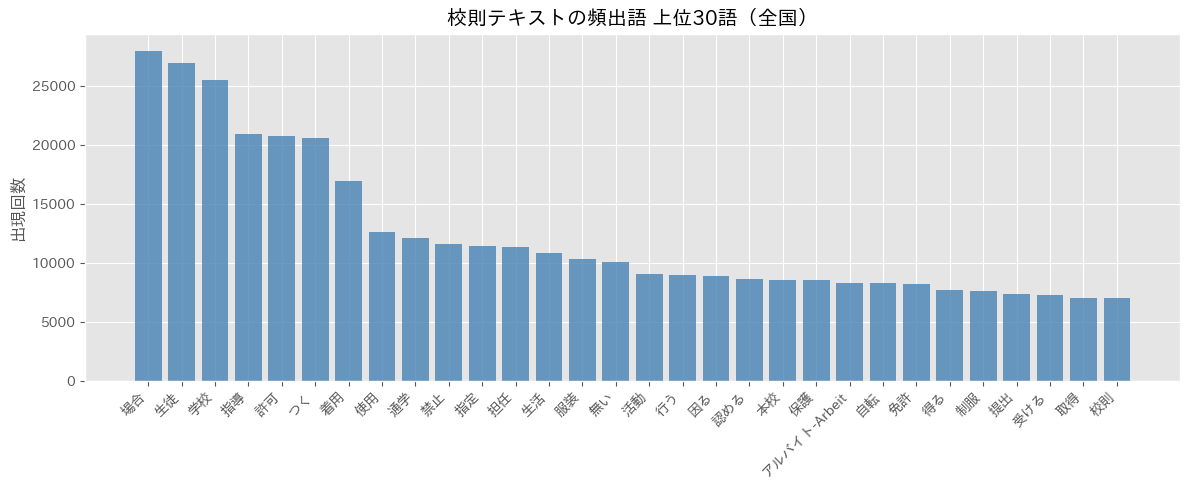

In [31]:
word_count_dict = dict()
for text in df_schools['clean_text']:
    for word in get_content_words(text):
        if word in word_count_dict:
            word_count_dict[word] = word_count_dict[word] + 1
        else:
            word_count_dict[word] = 1

word_series = pd.Series(word_count_dict)
top30 = word_series.sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(top30)), top30.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(top30)))
ax.set_xticklabels(top30.index.tolist(), rotation=45, ha='right')
ax.set_title('校則テキストの頻出語 上位30語（全国）')
ax.set_ylabel('出現回数')
plt.tight_layout()
plt.savefig('fig_word_freq.png', dpi=150)
plt.show()

「場合」「生徒」「着用」「禁止」「制服」などが上位に並んでおり、校則として適切なテキストが収集できていることが確認できた。

---

## 5. 自動アノテーション

先行研究（大森, 2023）では条文を手作業で分類した。本研究ではこの手作業を `in` 演算子によるパターンマッチングで自動化する。

### 5-1. アノテーションの設計

各条文にP（禁止）・O（義務）・R（推奨）・E（例外）・A（曖昧）・OTHERの6ラベルのいずれかを付与する。各ラベルは単語の表層形ではなく、**その表現が生徒をどのように制約・方向づけるか**という統治的機能の観点から定義した。

| ラベル | 定義 | 代表的な表現 |
|---|---|---|
| P（禁止） | 生徒の行為を直接制限・禁止する | 「禁止する」「してはならない」「認めない」 |
| O（義務） | 学校が特定の行動を義務として要求する | 「〜すること」「〜しなければならない」 |
| R（推奨） | 努力目標・望ましい行動を示す | 「心がける」「努める」「望ましい」 |
| E（例外） | 条件付きの許可や裁量を認める | 「ただし」「〜してよい」「可とする」 |
| A（曖昧） | 解釈を学校側に委ねる曖昧な規範を示す | 「高校生らしい」「華美でない」「節度ある」 |
| OTHER | 上記のいずれにも該当しない | 理念・前文・手続説明等 |

パターンリストは以下の手順で構築した。まず各ラベルの候補となる表現を列挙し、全ての条文（約22万件）に対して出現件数を集計した。出現頻度が高い表現ほど校則テキストにおいて安定して使われていると考えられるため、この頻度を根拠としてパターンリストを決定した。

In [32]:
candidate_patterns = {
    'P': ['禁止','してはならない','しないこと','禁ずる','禁じる','してはいけない',
          '慎む','許可なく','無断で','厳禁','控えること','認めない','不可',
          'いけない','行ってはならない','持ち込まない','没収','預かる',
          '指導の対象','特別指導'],
    'O': ['すること','しなければならない','でなければならない','遵守','着用する',
          '従うこと','するものとする','を守ること','してください','するように',
          'しなくてはならない','提出すること','届け出ること','申し出ること',
          '着用すること','連絡すること','行うこと','注意すること',
          '指定の','所定の','厳守','必ず','とする','義務'],
    'R': ['心がける','努める','望ましい','が好ましい','に努力','励む',
          'よう努める','を心がけ','推奨','基本とする',
          'に心がける','するよう心がけ','することが大切','求められる'],
    'E': ['ただし','やむを得ない','この限りではない','許可を得',
          'してもよい','することができる','を除く','場合に限り',
          '任意','自由とする','してよい','認める','でもよい',
          '可とする','許可される','場合はこの限り','承認を得た',
          '差し支えない','してもかまわない','この限りでない','特例','例外'],
    'A': ['高校生らしい','高校生として','生徒として','華美','節度','品位',
          'ふさわしい','常識','清潔','端正','適切','生徒らしい','良識',
          'にふさわしい','にふさわしくない','高校生らしく','マナー',
          '節度ある','相応しい','相応しくない','社会通念','見苦しくない'],
}

all_sentences = list()
for sents in df_schools['sentences']:
    all_sentences.extend(sents)

print('総条文数：', len(all_sentences))
print()
for label, patterns in candidate_patterns.items():
    print('=== ' + label + ' ===')
    pat_count = dict()
    for pat in patterns:
        count = sum(1 for s in all_sentences if pat in s)
        pat_count[pat] = count
    for pat, count in sorted(pat_count.items(), key=lambda x: x[1], reverse=True):
        print(str(count).rjust(6), '件  ', repr(pat))
    print()

総条文数： 209985

=== P ===
 11062 件   '禁止'
  3213 件   '認めない'
  3021 件   'しないこと'
  1794 件   'してはならない'
  1549 件   '特別指導'
  1143 件   '不可'
   750 件   '指導の対象'
   660 件   '厳禁'
   513 件   '許可なく'
   496 件   '無断で'
   481 件   'いけない'
   432 件   '慎む'
   430 件   '禁ずる'
   366 件   '持ち込まない'
   274 件   'してはいけない'
   227 件   '預かる'
    98 件   '行ってはならない'
    55 件   '禁じる'
    53 件   '没収'
    38 件   '控えること'

=== O ===
 24229 件   'とする'
 14890 件   'すること'
  6857 件   '着用する'
  6642 件   '指定の'
  5384 件   '必ず'
  4346 件   '所定の'
  2065 件   '着用すること'
  1659 件   'してください'
  1518 件   'しなければならない'
  1427 件   '遵守'
  1041 件   '提出すること'
  1020 件   '行うこと'
   994 件   '届け出ること'
   731 件   '厳守'
   597 件   'するものとする'
   538 件   'を守ること'
   461 件   '連絡すること'
   421 件   '注意すること'
   397 件   '従うこと'
   387 件   '義務'
   378 件   '申し出ること'
   288 件   'するように'
   187 件   'でなければならない'
     7 件   'しなくてはならない'

=== R ===
  1621 件   '努める'
  1418 件   '心がける'
   842 件   'を心がけ'
   567 件   'に心がける'
   534 件   '望ましい'
   190 件   'に努力'
   172 件   'よう努める'
   153 件   '

上記の集計結果をもとに、最終的なパターンリストを確定した。

`不可` については「不可欠」「不可能」への誤検出リスクがあるため `不可とする`・`は不可` の形で採用した。`認める`・`任意` は前後の文脈によって意味が変わるため `を認める`・`任意とする` と指定した。`没収`・`預かる`・`指導の対象`・`特別指導` は違反後の対応を示す表現であるため Pラベルから除外した。`とする` はOラベルの最多候補（24,243件）だが定義文に頻出するため除外した。

またAラベルは当初存在しなかった。しかし「高校生らしい」「華美でない」など、明示的な禁止ではないものの解釈を学校に委ねる曖昧なルールが多数存在することが判明したため、追加した。これらは解釈権が学校側にある裁量的統治として機能する点で、明示的禁止とは本質的に異なる。

### 5-2. アノテーションの実装

集計結果を踏まえ、最終的なパターンリストを以下のように確定した。ラベルの優先順位は OTHER（精神条文を早期除外）→ P → E → O → A → R → OTHER（未分類）とした。EをOより先に判定する理由は、「やむを得ない場合は担任に届け出ること」のようにEとOの両パターンが同時に出現する文ではEを優先すべきであるためである。またOをAより先に判定する理由は、「服装は端正でなければならない」のように義務文の中に曖昧語が含まれる場合、文全体の性格は義務であるためである。

In [33]:
OTHER_PATS = [
    '目指し','の精神に則','に貢献','の自覚を持','人間として',
    'を目的とする','の向上を図','本校生徒は','を培う',
]
P_PATS = [
    '禁止','してはならない','しないこと','を禁ずる','してはいけない','慎む',
    '行ってはならない','許可なく','無断で','厳禁','控えること','認めない',
    '不可とする','は不可','許可しない','いけない','を持ち込まない','持ち込み禁止',
]
O_PATS = [
    'すること','しなければならない','でなければならない','を遵守','着用する',
    '従うこと','するものとする','しなくてはならない','届け出ること',
    '申し出ること','提出すること','を着用すること','連絡すること',
    'を行うこと','注意すること',
]
R_PATS = [
    '心がける','努める','望ましい','が好ましい','に努力','励む',
    'よう努める','を心がけ','に心がける','するよう心がけ','することが大切',
]
E_PATS = [
    'ただし','やむを得ない','この限りでない','この限りではない','許可を得',
    'してもよい','することができる','を除く','場合に限り','任意とする',
    '自由とする','してよい','を認める','でもよい','可とする',
    '許可される','場合はこの限り','承認を得た','差し支えない','してもかまわない',
]
A_PATS = [
    '高校生らしい','高校生として','生徒として','華美','節度','品位',
    'ふさわしい','清潔感','端正','適切','生徒らしい','にふさわしい',
    'にふさわしくない','高校生らしく','節度ある','相応しい',
    '相応しくない','社会通念','良識','見苦しくない',
]

def annotate(sentence):
    for pat in OTHER_PATS:
        if pat in sentence: return 'OTHER'
    for pat in P_PATS:
        if pat in sentence: return 'P'
    for pat in E_PATS:
        if pat in sentence: return 'E'
    for pat in O_PATS:
        if pat in sentence: return 'O'
    for pat in A_PATS:
        if pat in sentence: return 'A'
    for pat in R_PATS:
        if pat in sentence: return 'R'
    return 'OTHER'

In [34]:
# 動作確認
test_cases = [
    ('P',     '携帯電話の使用を禁止する。'),
    ('P',     'ジャンバー類の着用は認めない。'),
    ('P',     '許可なく外出してはならない。'),
    ('O',     '制服を着用すること。'),
    ('O',     '服装は質素で端正でなければならない。'),
    ('R',     '礼儀正しく行動するよう心がける。'),
    ('E',     'やむを得ない場合は担任に申し出ること。'),
    ('E',     'ただし、学校行事の場合はこの限りでない。'),
    ('E',     'セーターの着用を認める。'),
    ('A',     '高校生らしい頭髪を心がけること。'),
    ('A',     '華美でない服装とする。'),
    ('OTHER', '本校生徒は豊かな人間性を目指す。'),
]
all_pass = True
for expected, sent in test_cases:
    pred = annotate(sent)
    mark = '✓' if pred == expected else '✗'
    if pred != expected:
        all_pass = False
    print(' ', mark, '期待:', expected, ' 予測:', pred, ' ', sent)
print()
print('全テスト通過' if all_pass else '一部ミスあり → パターンを確認すること')

  ✓ 期待: P  予測: P   携帯電話の使用を禁止する。
  ✓ 期待: P  予測: P   ジャンバー類の着用は認めない。
  ✓ 期待: P  予測: P   許可なく外出してはならない。
  ✓ 期待: O  予測: O   制服を着用すること。
  ✓ 期待: O  予測: O   服装は質素で端正でなければならない。
  ✓ 期待: R  予測: R   礼儀正しく行動するよう心がける。
  ✓ 期待: E  予測: E   やむを得ない場合は担任に申し出ること。
  ✓ 期待: E  予測: E   ただし、学校行事の場合はこの限りでない。
  ✓ 期待: E  予測: E   セーターの着用を認める。
  ✓ 期待: A  予測: A   高校生らしい頭髪を心がけること。
  ✓ 期待: A  予測: A   華美でない服装とする。
  ✓ 期待: OTHER  予測: OTHER   本校生徒は豊かな人間性を目指す。

全テスト通過


### 5-3. 全校への適用

動作確認ができたので、全校の校則テキストにアノテーションを施す。

In [35]:
def count_labels(sentences):
    count_dict = {'P': 0, 'O': 0, 'R': 0, 'E': 0, 'A': 0, 'OTHER': 0}
    for s in sentences:
        count_dict[annotate(s)] += 1
    return pd.Series({
        'P_count': count_dict['P'], 'O_count': count_dict['O'],
        'R_count': count_dict['R'], 'E_count': count_dict['E'],
        'A_count': count_dict['A'], 'OTHER_count': count_dict['OTHER'],
    })

label_df   = df_schools['sentences'].apply(count_labels)
df_schools = pd.concat([df_schools, label_df], axis=1)
df_schools['scored_total'] = (
    df_schools['P_count'] + df_schools['O_count'] +
    df_schools['R_count'] + df_schools['E_count']
)

全校のラベル合計：
P_count         22857
O_count         20920
R_count          2837
E_count         12148
A_count          6526
OTHER_count    144697
dtype: int64

  P： 10.9 %
  O： 10.0 %
  R： 1.4 %
  E： 5.8 %
  A： 3.1 %
  OTHER： 68.9 %


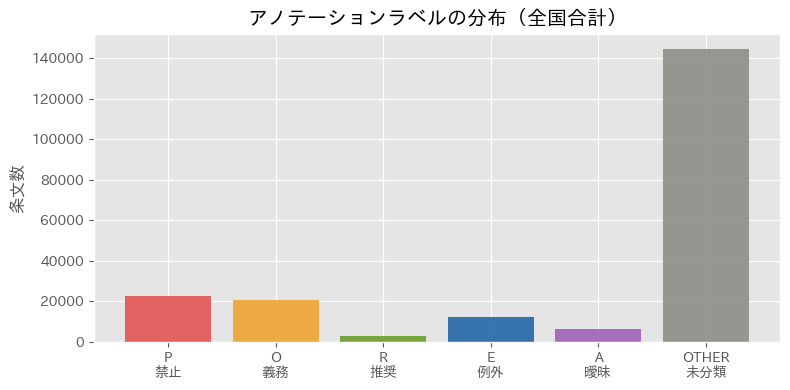

In [36]:
totals    = df_schools[['P_count','O_count','R_count','E_count','A_count','OTHER_count']].sum()
total_sum = totals.sum()

print('全校のラベル合計：')
print(totals)
print()
for label in ['P_count','O_count','R_count','E_count','A_count','OTHER_count']:
    print(' ', label.replace('_count','') + '：',
          round(totals[label] / total_sum * 100, 1), '%')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(['P\n禁止','O\n義務','R\n推奨','E\n例外','A\n曖昧','OTHER\n未分類'],
       totals.values,
       color=['#E24B4A','#EF9F27','#639922','#185FA5','#9B59B6','#888780'],
       alpha=0.85)
ax.set_title('アノテーションラベルの分布（全国合計）')
ax.set_ylabel('条文数')
plt.tight_layout()
plt.savefig('fig_label_dist.png', dpi=150)
plt.show()

約77%がOTHER（未分類）に分類された。当初この結果をアノテーション精度の失敗と捉えていたが、校則テキストを繰り返し確認する中で、この「失敗」自体が校則の本質を示している可能性に気づいた。校則には禁止や義務だけでなく、理念・人格形成・生活態度・教育方針といった記述が大量に含まれており、校則は単なる規則の集合ではなく「望ましい生徒像」を構築する教育的テキストとして機能していた。この発見についてはレポート本文の考察節で詳しく論じる。

---

## 6. 自由度スコアの算出

各学校の校則に対して、以下の式で自由度スコアを計算する。

$$\text{自由度スコア} = \frac{R \times 1 + E \times 2}{P \times 2 + O \times 1 + R \times 1 + E \times 2} \times 100$$

本スコアは、校則テキストにおいて許容・裁量を認める表現（R・E）が禁止・義務表現（P・O）に対してどの程度含まれるかを定量化したものである。EやRが多い学校ほどスコアは高くなり、PやOが多い学校ほどスコアは低くなる。重みはP・Eに2、O・Rに1を付与した。なおAラベルはスコア計算に含めず、別途集計する。

ただし、本指標は明文化された規範表現を対象としており、「そもそも規定が存在しない自由」は測定できないという限界を持つ。

### 6-1. 閾値の設定

scored_total（P+O+R+Eの合計）が10件未満の学校は、分母が小さすぎてスコアが実態を反映しない可能性がある。閾値の妥当性を確認するため、閾値を10・25・50に変えて分布の変化を比較した。

閾値 10 ：対象校数 = 1480
閾値 25 ：対象校数 = 975
閾値 50 ：対象校数 = 378


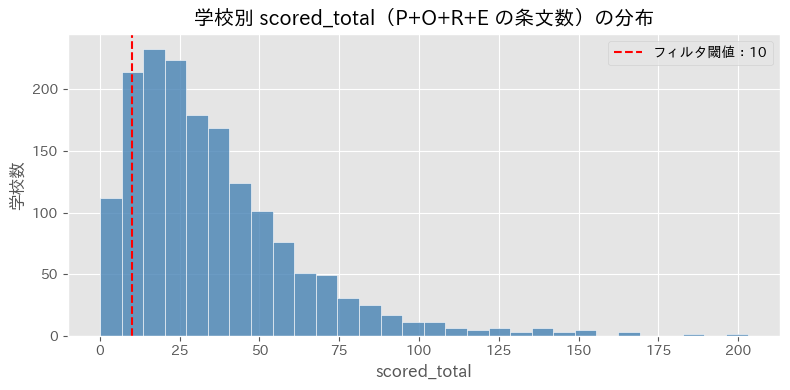

In [37]:
for threshold in [10, 25, 50]:
    n = df_schools['scored_total'].ge(threshold).sum()
    print('閾値', threshold, '：対象校数 =', n)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_schools['scored_total'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(10, color='red', linestyle='--', label='フィルタ閾値：10')
ax.set_title('学校別 scored_total（P+O+R+E の条文数）の分布')
ax.set_xlabel('scored_total')
ax.set_ylabel('学校数')
ax.legend()
plt.tight_layout()
plt.savefig('fig_scored_total.png', dpi=150)
plt.show()

閾値10と25で最小値・最大値・平均がほぼ同一であったため、分析対象を最大化する観点から閾値10を採用した。

### 6-2. 自由度スコアの算出

In [38]:
MIN_SCORED = 10

def calc_score(row):
    if row['scored_total'] < MIN_SCORED:
        return np.nan
    w_P, w_O, w_R, w_E = 2, 1, 1, 2
    numer = row['R_count'] * w_R + row['E_count'] * w_E
    denom = (row['P_count'] * w_P + row['O_count'] * w_O +
             row['R_count'] * w_R + row['E_count'] * w_E)
    if denom == 0:
        return np.nan
    return round(numer / denom * 100, 2)

df_schools['freedom_score'] = df_schools.apply(calc_score, axis=1)

print('自由度スコア算出校数：', df_schools['freedom_score'].notna().sum())
print()
print('自由度スコアの基本統計量：')
print(df_schools['freedom_score'].describe().round(2))

自由度スコア算出校数： 1480

自由度スコアの基本統計量：
count    1480.00
mean       29.14
std        13.35
min         0.00
25%        19.69
50%        28.00
75%        37.50
max        83.33
Name: freedom_score, dtype: float64


### 6-3. 自由度スコアの分布

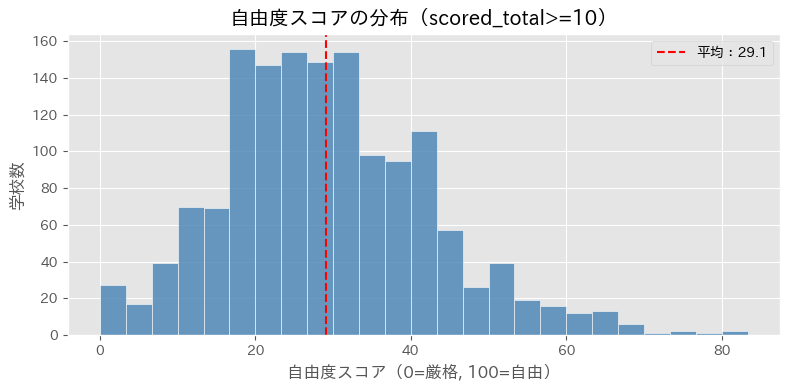

In [39]:
valid_scores = df_schools.loc[df_schools['freedom_score'].notna(), 'freedom_score']
mean_val = valid_scores.mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(valid_scores, bins=25, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(mean_val, color='red', linestyle='--', label='平均：' + str(round(mean_val, 1)))
ax.set_title('自由度スコアの分布（scored_total>=' + str(MIN_SCORED) + '）')
ax.set_xlabel('自由度スコア（0=厳格, 100=自由）')
ax.set_ylabel('学校数')
ax.legend()
plt.tight_layout()
plt.savefig('fig_freedom_hist.png', dpi=150)
plt.show()

In [40]:
# スコア上位・下位の確認（「規定されない自由」のパラドックスの確認）
df_valid = df_schools.loc[df_schools['freedom_score'].notna()]
print('自由度スコアが高い学校（上位10校）：')
print(df_valid.nlargest(10, 'freedom_score')[
    ['school_name','prefecture','freedom_score','scored_total','P_count','E_count']
].to_string(index=False))
print()
print('自由度スコアが低い学校（下位10校）：')
print(df_valid.nsmallest(10, 'freedom_score')[
    ['school_name','prefecture','freedom_score','scored_total','P_count','E_count']
].to_string(index=False))
print()
print('スコア上位10校の平均scored_total：', round(df_valid.nlargest(10,'freedom_score')['scored_total'].mean(), 1))
print('スコア下位10校の平均scored_total：', round(df_valid.nsmallest(10,'freedom_score')['scored_total'].mean(), 1))
print('全体の平均scored_total          ：', round(df_valid['scored_total'].mean(), 1))

自由度スコアが高い学校（上位10校）：
    school_name prefecture  freedom_score  scored_total  P_count  E_count
       盛岡第一高等学校      iwate          83.33            13        1       10
      茅ケ崎北陵高等学校   kanagawa          81.82            12        1        9
        弟子屈高等学校   hokkaido          78.79            21        0       12
        岩ケ崎高等学校     miyagi          76.19            14        0        7
五所川原高等学校(全日・定時)     aomori          75.00            12        1        3
         座間高等学校   kanagawa          70.00            11        2        7
        花巻南高等学校      iwate          69.57            14        3        6
       横浜南陵高等学校   kanagawa          69.44            22        4       10
       大宮光陵高等学校    saitama          67.50            21        6       13
       熊谷商業高等学校    saitama          66.67            11        1        6

自由度スコアが低い学校（下位10校）：
    school_name prefecture  freedom_score  scored_total  P_count  E_count
        訓子府高等学校   hokkaido            0.0            11        9       

---

## 7. 偏差値データとの結合

kousoku.orgと高校偏差値.netでは学校名の表記が異なる場合がある。たとえば「札幌北高等学校（全日・定時）」と「札幌北高校」のような違いである。以下の手順で学校名を正規化（名寄せ）した後、都道府県と学校名の2変数をキーに `pd.merge` でinner joinする。

1. 設置者名（「東京都立」「神奈川県立」等）を `.replace()` で除去
2. 「高等学校」を `.replace()` で「高校」に統一
3. 「（」・「(」以降の課程・学科情報を `.split()` で除去

inner joinを選択した理由は、両方のデータセットに存在する学校のみを分析対象とするためである。

In [41]:
SETSUBISHA = [
    '北海道立','東京都立','大阪府立','京都府立',
    '青森県立','岩手県立','宮城県立','秋田県立','山形県立','福島県立',
    '茨城県立','栃木県立','群馬県立','埼玉県立','千葉県立','神奈川県立',
    '新潟県立','富山県立','石川県立','福井県立','山梨県立','長野県立',
    '静岡県立','愛知県立','岐阜県立','三重県立',
    '滋賀県立','兵庫県立','奈良県立','和歌山県立',
    '鳥取県立','島根県立','岡山県立','広島県立','山口県立',
    '徳島県立','香川県立','愛媛県立','高知県立',
    '福岡県立','佐賀県立','長崎県立','熊本県立','大分県立',
    '宮崎県立','鹿児島県立','沖縄県立',
    '市立','区立','町立','村立',
]

def normalize_name(name):
    name = str(name)
    for s in SETSUBISHA:
        name = name.replace(s, '')
    name = name.replace('高等学校', '高校').replace('高等専門学校', '高専')
    if '（' in name: name = name.split('（')[0]
    if '(' in name:  name = name.split('(')[0]
    return name.strip()

In [42]:
# 動作確認
check_pairs = [
    ('札幌北高等学校(全日・定時)', '札幌北高校'),
    ('東京都立多摩高等学校',       '多摩高校'),
    ('函館中部高等学校(全日・定時)','函館中部高校'),
]
for before, expected in check_pairs:
    result = normalize_name(before)
    mark = '✓' if result == expected else '✗'
    print(' ', mark, before, '→', result)

  ✓ 札幌北高等学校(全日・定時) → 札幌北高校
  ✓ 東京都立多摩高等学校 → 多摩高校
  ✓ 函館中部高等学校(全日・定時) → 函館中部高校


In [43]:
df_schools['name_norm']    = df_schools['school_name'].apply(normalize_name)
hensachi_did['name_norm'] = hensachi_did['school_name'].apply(normalize_name)

# 同一校に複数の学科がある場合は学校単位で集約する
df_h_dedup = (
    hensachi_did
    .groupby(['prefecture', 'name_norm'], as_index=False, observed=True)
    .apply(lambda g: pd.Series({
        'hensachi':      g['hensachi'].max(),
        'gender':        aggregate_gender(g['gender']),
        'gakka':         aggregate_gakka(g['gakka']),
        'did_ratio':     g['did_ratio'].iloc[0],
        'prefecture_ja': g['prefecture_ja'].iloc[0],
    }))
    .reset_index(drop=True)
)

df_merged = pd.merge(df_schools, df_h_dedup, on=['prefecture','name_norm'], how='inner')

print('校則データ件数  ：', len(df_schools))
print('偏差値データ件数：', len(df_h_dedup))
print('結合後件数      ：', len(df_merged))
print('マッチ率        ：', round(len(df_merged) / len(df_schools) * 100, 1), '%')

校則データ件数  ： 1666
偏差値データ件数： 3330
結合後件数      ： 1561
マッチ率        ： 93.7 %


/var/folders/9v/t_x78pcj1x5c11t91l365mtw0000gn/T/ipykernel_19756/1908173122.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


マッチングに失敗した主な原因は、分校・通信制校・定時制校など高校偏差値.netに掲載のない学校の存在であった。

In [44]:
# 最終分析対象の確定
df_ana = df_merged.loc[
    df_merged['hensachi'].notna() &
    df_merged['freedom_score'].notna() &
    df_merged['did_ratio'].notna(),
:].copy()

df_ana['hensachi']  = df_ana['hensachi'].astype(float)
df_ana['did_ratio'] = df_ana['did_ratio'].astype(float)

# ダミー変数の作成
df_ana['is_girl']   = df_ana['gender'].apply(lambda x: 1 if x == '女子' else 0)
df_ana['is_boy']    = df_ana['gender'].apply(lambda x: 1 if x == '男子' else 0)

SENMON_WORDS = ['工業','商業','農業','水産','家政','看護','福祉','芸術','体育','理数']
def check_senmon(gakka):
    for s in SENMON_WORDS:
        if s in str(gakka): return 1
    return 0

df_ana['is_senmon'] = df_ana['gakka'].apply(check_senmon)

print('最終分析対象：', len(df_ana), '校')
print()
print('ダミー変数の内訳：')
print('女子校  ：', df_ana['is_girl'].sum(), '校')
print('男子校  ：', df_ana['is_boy'].sum(),  '校')
print('専門高校：', df_ana['is_senmon'].sum(),'校')
print()
print('基本統計量：')
print(df_ana[['hensachi','did_ratio','freedom_score','is_girl','is_boy','is_senmon']].describe().round(2))

最終分析対象： 1406 校

ダミー変数の内訳：
女子校  ： 15 校
男子校  ： 9 校
専門高校： 58 校

基本統計量：
       hensachi  did_ratio  freedom_score  is_girl   is_boy  is_senmon
count   1406.00    1406.00        1406.00  1406.00  1406.00    1406.00
mean      49.22      51.38          29.29     0.01     0.01       0.04
std        9.22      37.19          13.16     0.10     0.08       0.20
min       36.00       0.00           0.00     0.00     0.00       0.00
25%       42.00      13.20          20.00     0.00     0.00       0.00
50%       47.00      56.35          28.06     0.00     0.00       0.00
75%       55.00      88.08          37.72     0.00     0.00       0.00
max       75.00     100.00          83.33     1.00     1.00       1.00


---

## 8. 収集データの概要

In [45]:
print('=' * 55)
print('            データ収集・加工の概要')
print('=' * 55)
print('kousoku.org 収集校数    ：', len(df_schools))
print('偏差値データ（公立）    ：', len(hensachi_did))
print('名寄せ後マッチ数        ：', len(df_merged))
print('最終分析対象            ：', len(df_ana), '校')
print()
print('先行研究（大森, 2023）  ：32校（手動分類）')
print('本研究                  ：' + str(len(df_ana)) + '校（自動アノテーション）')
print('=' * 55)

            データ収集・加工の概要
kousoku.org 収集校数    ： 1666
偏差値データ（公立）    ： 6301
名寄せ後マッチ数        ： 1561
最終分析対象            ： 1406 校

先行研究（大森, 2023）  ：32校（手動分類）
本研究                  ：1406校（自動アノテーション）


---

## 9. データ分析・可視化

### 9-1. 相関ヒートマップ

分析の前に、主要変数間の相関関係を `df.corr()` で確認する。どの変数が自由度スコアと関連しているかを俯瞰的に把握することが目的である。

相関行列：
               hensachi  did_ratio  is_girl  is_boy  is_senmon  freedom_score  \
hensachi          1.000      0.347    0.130   0.141     -0.080          0.135   
did_ratio         0.347      1.000    0.025   0.007     -0.062          0.054   
is_girl           0.130      0.025    1.000  -0.008     -0.022          0.038   
is_boy            0.141      0.007   -0.008   1.000     -0.017         -0.033   
is_senmon        -0.080     -0.062   -0.022  -0.017      1.000         -0.022   
freedom_score     0.135      0.054    0.038  -0.033     -0.022          1.000   
P_count          -0.142     -0.240   -0.065  -0.042      0.072         -0.276   
char_count       -0.047     -0.230   -0.047  -0.044      0.018          0.070   

               P_count  char_count  
hensachi        -0.142      -0.047  
did_ratio       -0.240      -0.230  
is_girl         -0.065      -0.047  
is_boy          -0.042      -0.044  
is_senmon        0.072       0.018  
freedom_score   -0.276       0.070  
P_cou

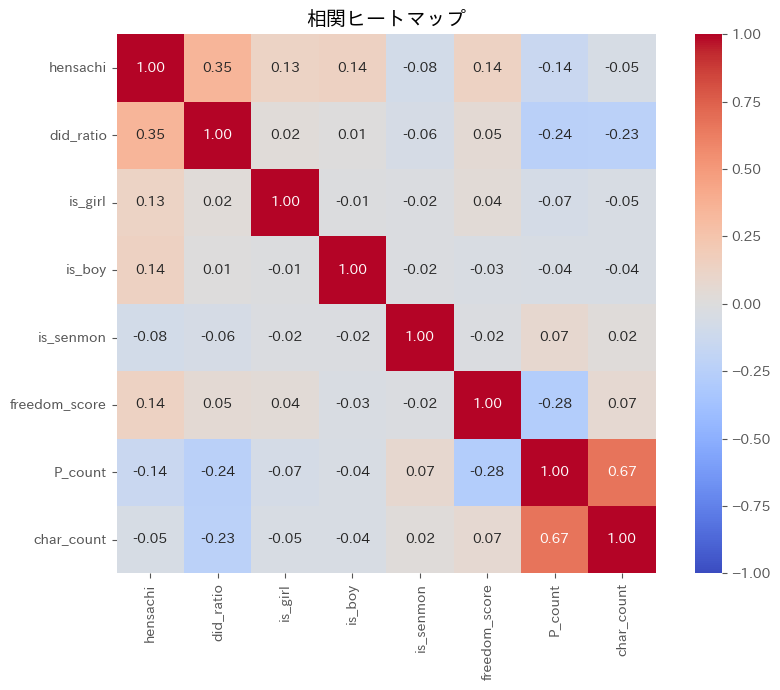

In [46]:
cols = ['hensachi','did_ratio','is_girl','is_boy','is_senmon',
        'freedom_score','P_count','char_count']
corr = df_ana[cols].corr()

print('相関行列：')
print(corr.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('相関ヒートマップ')
plt.tight_layout()
plt.savefig('fig_heatmap.png', dpi=150)
plt.show()

### 9-2. 重回帰分析（自由度スコア）

以下のモデルで重回帰分析を実施する。

$$\text{自由度スコア} = \beta_0 + \beta_1 \text{偏差値} + \beta_2 \text{DID比率} + \beta_3 \text{女子校} + \beta_4 \text{男子校} + \beta_5 \text{専門高校} + \varepsilon$$

偏差値以外の交絡変数（都市度・学校属性）を統制した上で偏差値の独立した効果を推定することが目的である。使用パッケージはstatsmodels（OLS）。p < 0.05 のとき統計的に有意と判断する。

**DID比率の変換について**

DID比率は0（農村）〜100（都市）の範囲をとるが、分布が右裾に集中している可能性がある。以下では線形モデルに加え、対数変換（`log1p`）とカテゴリ化（低・中・高）の3種類を比較する。

In [47]:
X_cols = ['hensachi', 'did_ratio', 'is_girl', 'is_boy', 'is_senmon']
X = sm.add_constant(df_ana[X_cols].copy())
y = df_ana['freedom_score']

model_freedom = sm.OLS(y, X).fit()
print(model_freedom.summary())

                            OLS Regression Results                            
Dep. Variable:          freedom_score   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     6.140
Date:                Sat, 30 May 2026   Prob (F-statistic):           1.23e-05
Time:                        06:10:19   Log-Likelihood:                -5603.3
No. Observations:                1406   AIC:                         1.122e+04
Df Residuals:                    1400   BIC:                         1.125e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.6166      1.937     10.127      0.0

In [48]:
# DID比率の変換バージョンも試す
df_ana['log_did'] = np.log1p(df_ana['did_ratio'])

df_ana['did_group'] = pd.cut(
    df_ana['did_ratio'],
    bins=[-1, 20, 60, 100],
    labels=['低（0-20%）', '中（20-60%）', '高（60-100%）']
)
df_ana['did_high'] = (df_ana['did_ratio'] >= 60).astype(int)  # 高DIDダミー

print('=== DID比率の分布 ===')
print(df_ana['did_group'].value_counts().sort_index())
print()

# 対数変換モデル
X_log = sm.add_constant(df_ana[['hensachi','log_did','is_girl','is_boy','is_senmon']].copy())
model_log = sm.OLS(y, X_log).fit()
print('=== 対数変換モデルのDID係数 ===')
print('β(log_did) =', round(model_log.params['log_did'], 4),
      '  p =', round(model_log.pvalues['log_did'], 4))
print()

# ダミー変数モデル（高DID vs その他）
X_dum = sm.add_constant(df_ana[['hensachi','did_high','is_girl','is_boy','is_senmon']].copy())
model_dum = sm.OLS(y, X_dum).fit()
print('=== 高DIDダミーモデルのDID係数 ===')
print('β(did_high) =', round(model_dum.params['did_high'], 4),
      '  p =', round(model_dum.pvalues['did_high'], 4))

=== DID比率の分布 ===
did_group
低（0-20%）      400
中（20-60%）     359
高（60-100%）    647
Name: count, dtype: int64

=== 対数変換モデルのDID係数 ===
β(log_did) = -0.0723   p = 0.73

=== 高DIDダミーモデルのDID係数 ===
β(did_high) = 0.046   p = 0.9497


In [49]:
# 3モデルの比較
print('=== DID変換3モデルの比較 ===')
print(f'{'モデル':20s}  {'R²':>8s}  {'β(DID)':>10s}  {'p(DID)':>8s}')
print('-' * 55)
for label, model, var in [
    ('線形（did_ratio）',  model_freedom, 'did_ratio'),
    ('対数（log_did）',    model_log,     'log_did'),
    ('ダミー（高DID）',    model_dum,     'did_high'),
]:
    r2   = round(model.rsquared, 4)
    coef = round(model.params[var], 4)
    pval = round(model.pvalues[var], 4)
    sig  = '**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.')
    print(f'{label:20s}  {r2:8.4f}  {coef:10.4f}  {pval:8.4f} {sig}')

=== DID変換3モデルの比較 ===
モデル                         R²      β(DID)    p(DID)
-------------------------------------------------------
線形（did_ratio）           0.0215      0.0020    0.8418 n.s.
対数（log_did）             0.0215     -0.0723    0.7300 n.s.
ダミー（高DID）               0.0214      0.0460    0.9497 n.s.


In [50]:
# 採用モデルの係数整理
print('=== 採用モデル：自由度スコアの重回帰分析結果 ===')
print('サンプル数       ：', int(model_freedom.nobs))
print('決定係数 R²      ：', round(model_freedom.rsquared, 4))
print('自由度調整済み R²：', round(model_freedom.rsquared_adj, 4))
print('F統計量          ：', round(model_freedom.fvalue, 4),
      '  p =', round(model_freedom.f_pvalue, 6))
print()
print('各係数：')
for var in X_cols:
    coef = round(model_freedom.params[var], 4)
    pval = round(model_freedom.pvalues[var], 4)
    sig  = '**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.')
    print(f'  {var:12s}：β = {coef:8.4f}  p = {pval:.4f}  {sig}')

=== 採用モデル：自由度スコアの重回帰分析結果 ===
サンプル数       ： 1406
決定係数 R²      ： 0.0215
自由度調整済み R²： 0.018
F統計量          ： 6.1403   p = 1.2e-05

各係数：
  hensachi    ：β =   0.1956  p = 0.0000  **
  did_ratio   ：β =   0.0020  p = 0.8418  n.s.
  is_girl     ：β =   2.4459  p = 0.4743  n.s.
  is_boy      ：β =  -8.5731  p = 0.0523  n.s.
  is_senmon   ：β =  -0.7221  p = 0.6811  n.s.


### 9-3. 重回帰分析（禁止条文数）

自由度スコアは複数ラベルを合成した指標であるため、より解釈が明確な禁止条文数（P_count）を従属変数とした同一モデルでも分析を行う。相関ヒートマップで偏差値との相関が最も強いのはP_countであり、「偏差値が高い学校ほど禁止条文が少ない」という命題を直接検証する。

In [51]:
model_pcount = sm.OLS(df_ana['P_count'], X).fit()

print('=== 禁止条文数の重回帰分析結果 ===')
print('サンプル数       ：', int(model_pcount.nobs))
print('決定係数 R²      ：', round(model_pcount.rsquared, 4))
print('自由度調整済み R²：', round(model_pcount.rsquared_adj, 4))
print()
for var in X_cols:
    coef = round(model_pcount.params[var], 4)
    pval = round(model_pcount.pvalues[var], 4)
    sig  = '**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.')
    print(f'  {var:12s}：β = {coef:8.4f}  p = {pval:.4f}  {sig}')

=== 禁止条文数の重回帰分析結果 ===
サンプル数       ： 1406
決定係数 R²      ： 0.0683
自由度調整済み R²： 0.065

  hensachi    ：β =  -0.0576  p = 0.0681  n.s.
  did_ratio   ：β =  -0.0607  p = 0.0000  **
  is_girl     ：β =  -5.2584  p = 0.0454  *
  is_boy      ：β =  -4.3002  p = 0.2048  n.s.
  is_senmon   ：β =   2.7466  p = 0.0419  *


### 9-4. 多重共線性の確認（VIF）

重回帰分析の前提として、説明変数間に強い多重共線性がないことを確認する。VIF（分散拡大係数）が10を超える場合は問題となる可能性がある。

In [52]:
X_vif = sm.add_constant(df_ana[X_cols].copy())
vif_df = pd.DataFrame()
vif_df['variable'] = X_vif.columns
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i)
                 for i in range(X_vif.shape[1])]
print('VIF（分散拡大係数）：')
print(vif_df.to_string(index=False))
print()
print('（VIF < 10 であれば多重共線性は問題ない）')

VIF（分散拡大係数）：
 variable       VIF
    const 30.996097
 hensachi  1.186532
did_ratio  1.141035
  is_girl  1.018526
   is_boy  1.023272
is_senmon  1.007911

（VIF < 10 であれば多重共線性は問題ない）


### 9-5. 偏差値帯別の分析

`pd.cut` で偏差値を6段階にカテゴリ化し、各グループの平均自由度スコアとラベル構成比を `groupby` + `agg` で集計・可視化する。回帰分析の結果を補完する形で、偏差値帯ごとの傾向を確認することが目的である。

In [53]:
df_ana['hensachi_band'] = pd.cut(
    df_ana['hensachi'],
    bins=[0, 44, 49, 54, 59, 64, 100],
    labels=['44以下', '45-49', '50-54', '55-59', '60-64', '65以上']
)

band_summary = df_ana.groupby('hensachi_band', observed=True).agg(
    n          = ('freedom_score', 'count'),
    score_mean = ('freedom_score', 'mean'),
    score_std  = ('freedom_score', 'std'),
    P_mean     = ('P_count', 'mean'),
    O_mean     = ('O_count', 'mean'),
    did_mean   = ('did_ratio', 'mean'),
    char_mean  = ('char_count', 'mean'),
).round(2)

print('偏差値帯別の集計：')
print(band_summary)

偏差値帯別の集計：
                 n  score_mean  score_std  P_mean  O_mean  did_mean  char_mean
hensachi_band                                                                 
44以下           563       27.64      13.22   16.30   15.41     37.45    4791.11
45-49          275       28.30      12.31   16.28   14.13     53.23    4577.23
50-54          193       30.12      12.52   16.46   14.55     59.46    5002.40
55-59          138       31.50      13.51   13.18   11.75     61.04    3824.93
60-64          113       32.47      12.74   13.85   12.73     65.95    4659.08
65以上           124       32.31      14.44   11.10   11.47     73.94    4185.68


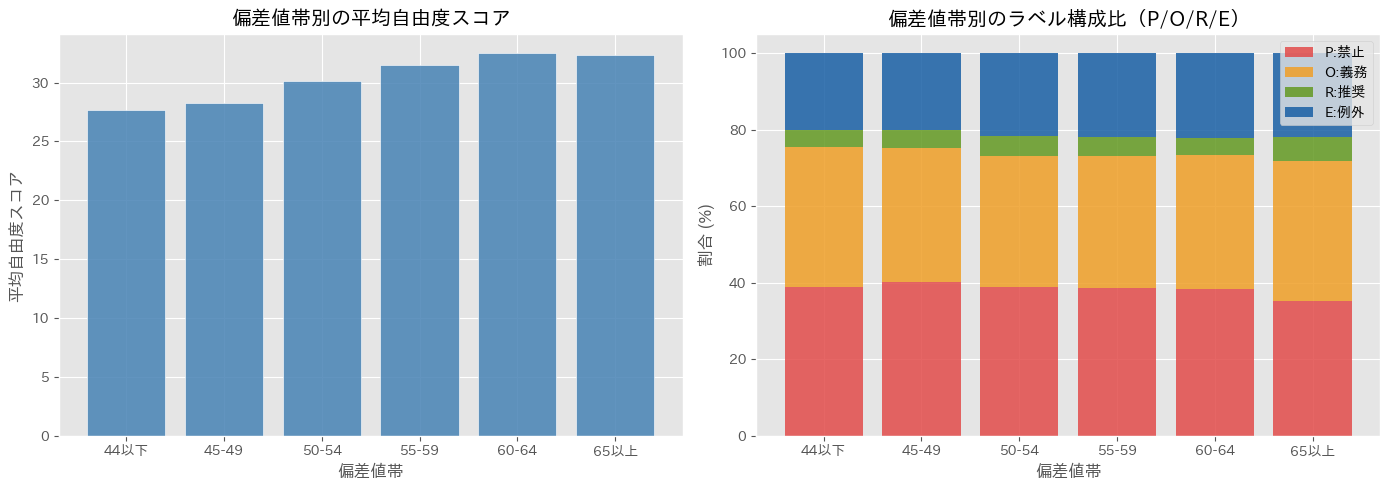

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
band_labels = band_summary.index.tolist()

axes[0].bar(band_labels, band_summary['score_mean'].tolist(),
            color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_title('偏差値帯別の平均自由度スコア')
axes[0].set_xlabel('偏差値帯')
axes[0].set_ylabel('平均自由度スコア')

ratio     = df_ana.groupby('hensachi_band', observed=True)[
    ['P_count','O_count','R_count','E_count']].mean()
ratio_pct = ratio.div(ratio.sum(axis=1), axis=0) * 100

bottoms = [0.0] * len(ratio_pct)
for col, color, lname in zip(
    ['P_count','O_count','R_count','E_count'],
    ['#E24B4A','#EF9F27','#639922','#185FA5'],
    ['P:禁止','O:義務','R:推奨','E:例外']
):
    vals = ratio_pct[col].tolist()
    axes[1].bar(ratio_pct.index.tolist(), vals, bottom=bottoms,
                color=color, alpha=0.85, label=lname)
    bottoms = [bottoms[i] + vals[i] for i in range(len(vals))]

axes[1].set_title('偏差値帯別のラベル構成比（P/O/R/E）')
axes[1].set_xlabel('偏差値帯')
axes[1].set_ylabel('割合 (%)')
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig_band_analysis.png', dpi=150)
plt.show()

### 9-6. 散布図（偏差値 × 自由度スコア）

偏差値と自由度スコアの関係を散布図で可視化する。回帰直線は最小二乗法で手計算して描画する。

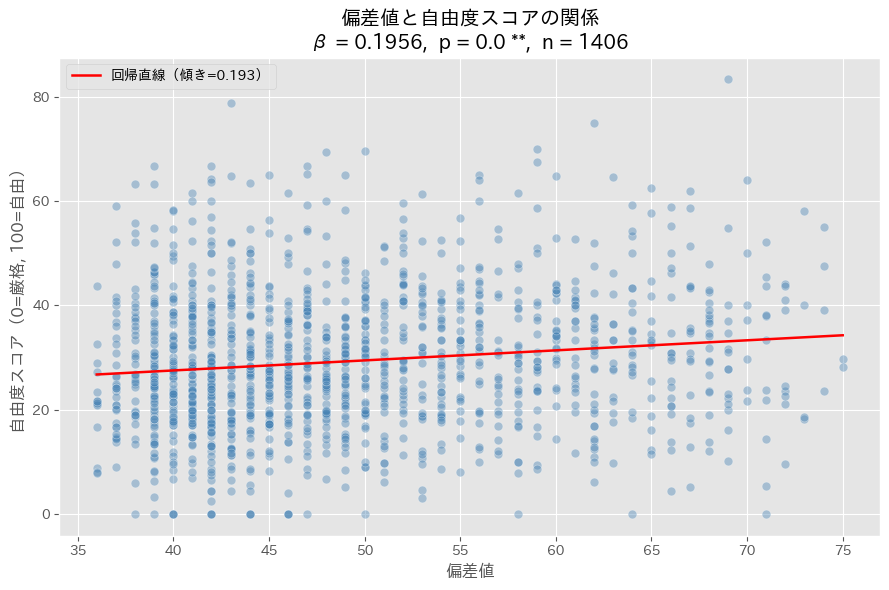

In [55]:
x_s = df_ana['hensachi']
y_s = df_ana['freedom_score']
slope     = ((x_s - x_s.mean()) * (y_s - y_s.mean())).sum() / ((x_s - x_s.mean()) ** 2).sum()
intercept = y_s.mean() - slope * x_s.mean()

beta_h = round(model_freedom.params['hensachi'], 4)
pval_h = round(model_freedom.pvalues['hensachi'], 4)
sig_h  = '**' if pval_h < 0.01 else ('*' if pval_h < 0.05 else 'n.s.')

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x_s.values, y_s.values, alpha=0.4, s=40,
           color='steelblue', edgecolors='white', linewidth=0.5)
ax.plot([x_s.min(), x_s.max()],
        [slope * x_s.min() + intercept, slope * x_s.max() + intercept],
        color='red', linewidth=1.8, label='回帰直線（傾き=' + str(round(slope, 3)) + '）')
ax.set_title(
    '偏差値と自由度スコアの関係\n'
    + 'β = ' + str(beta_h) + ',  p = ' + str(pval_h) + ' ' + sig_h
    + ',  n = ' + str(len(df_ana))
)
ax.set_xlabel('偏差値')
ax.set_ylabel('自由度スコア（0=厳格, 100=自由）')
ax.legend()
plt.tight_layout()
plt.savefig('fig_scatter_main.png', dpi=150)
plt.show()

---

## 10. 分析サマリー

本ノートブックで実施した分析の結果を整理する。以下の数値はレポート本文の各章に記載した数値と対応している。

In [56]:
print('=' * 60)
print('                    分析サマリー')
print('=' * 60)
print('収集校数（kousoku.org）    ：', len(df_schools))
print('偏差値データ（公立）       ：', len(hensachi_did))
print('名寄せ後マッチ数           ：', len(df_merged))
print('最終分析対象               ：', len(df_ana), '校')
print()
print('--- 変数の記述統計 ---')
for col, label in [('hensachi','偏差値'),('did_ratio','DID比率'),('freedom_score','自由度スコア')]:
    print(f'  {label:12s}  平均={round(df_ana[col].mean(),2):7.2f}  SD={round(df_ana[col].std(),2):6.2f}')
print()
print('--- 重回帰：自由度スコア ---')
print('R²      ：', round(model_freedom.rsquared, 4))
print('adj R²  ：', round(model_freedom.rsquared_adj, 4))
for var in X_cols:
    coef = round(model_freedom.params[var], 4)
    pval = round(model_freedom.pvalues[var], 4)
    sig  = '**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.')
    print(f'  {var:12s}：β={coef:8.4f}  p={pval:.4f}  {sig}')
print()
print('--- 重回帰：禁止条文数 ---')
print('R²      ：', round(model_pcount.rsquared, 4))
print('adj R²  ：', round(model_pcount.rsquared_adj, 4))
for var in X_cols:
    coef = round(model_pcount.params[var], 4)
    pval = round(model_pcount.pvalues[var], 4)
    sig  = '**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.')
    print(f'  {var:12s}：β={coef:8.4f}  p={pval:.4f}  {sig}')
print('=' * 60)

                    分析サマリー
収集校数（kousoku.org）    ： 1666
偏差値データ（公立）       ： 6301
名寄せ後マッチ数           ： 1561
最終分析対象               ： 1406 校

--- 変数の記述統計 ---
  偏差値           平均=  49.22  SD=  9.22
  DID比率         平均=  51.38  SD= 37.19
  自由度スコア        平均=  29.29  SD= 13.16

--- 重回帰：自由度スコア ---
R²      ： 0.0215
adj R²  ： 0.018
  hensachi    ：β=  0.1956  p=0.0000  **
  did_ratio   ：β=  0.0020  p=0.8418  n.s.
  is_girl     ：β=  2.4459  p=0.4743  n.s.
  is_boy      ：β= -8.5731  p=0.0523  n.s.
  is_senmon   ：β= -0.7221  p=0.6811  n.s.

--- 重回帰：禁止条文数 ---
R²      ： 0.0683
adj R²  ： 0.065
  hensachi    ：β= -0.0576  p=0.0681  n.s.
  did_ratio   ：β= -0.0607  p=0.0000  **
  is_girl     ：β= -5.2584  p=0.0454  *
  is_boy      ：β= -4.3002  p=0.2048  n.s.
  is_senmon   ：β=  2.7466  p=0.0419  *
